# Kriging — Fold 0 evaluation

Loads `outputs/kriging/kfold/fold0_predictions.parquet` (with S3 fallback), computes metrics and plots diagnostics for all 9 (transform × variogram_model) combinations.

Input parquet schema (from `thesis.models.kriging.kfold_worker`):
`date, station_id, observed_mm, observed_quota, predicted_mm, predicted_var_mm2, predicted_z, predicted_z_var, transform, variogram_model, fold`.

Metrics: RMSE, MAE, bias, CRPS (gaussian closed form via `predicted_var_mm2`), 80%/90% coverage — over all days and wet-only (obs ≥ 0.1 mm).

Plots: metric bar charts across the 9 combos, pred-vs-obs scatter for the winner, per-station RMSE map, sample station time series.

In [1]:
import sys
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import properscoring as ps

ROOT = Path('../..')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

from thesis.config import Config
cfg = Config()
print('imports OK')

imports OK


## 1. Load predictions (S3 fallback)

In [2]:
FOLD       = 0
S3_BUCKET  = 'thesis-data-ismaktam'
S3_ROOT    = 'kriging'
OUT_DIR    = Path('outputs/kriging')
KFOLD_DIR  = OUT_DIR / 'kfold'
EVAL_DIR   = OUT_DIR / 'eval' / f'fold{FOLD}'
KFOLD_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

pred_local = KFOLD_DIR / f'fold{FOLD}_predictions.parquet'
pred_s3    = f'{S3_ROOT}/kfold/fold{FOLD}_predictions.parquet'

if not pred_local.exists():
    import boto3
    print(f'  downloading s3://{S3_BUCKET}/{pred_s3} ...')
    boto3.client('s3').download_file(S3_BUCKET, pred_s3, str(pred_local))
print(f'  loaded: {pred_local} ({pred_local.stat().st_size/1e6:.0f} MB)')

df = pd.read_parquet(pred_local)
df['date'] = pd.to_datetime(df['date'])

print(f'\nrows:               {len(df):,}')
print(f'unique dates:       {df["date"].nunique():,}')
print(f'unique stations:    {df["station_id"].nunique()}')
print(f'transforms:         {sorted(df["transform"].unique())}')
print(f'variogram_models:   {sorted(df["variogram_model"].unique())}')
print(f'date range:         {df["date"].min().date()} → {df["date"].max().date()}')
print(f'\nmissing predictions: {df["predicted_mm"].isna().sum():,}')
print(f'missing variances:   {df["predicted_var_mm2"].isna().sum():,}')
df.head()

  loaded: outputs/kriging/kfold/fold0_predictions.parquet (1936 MB)

rows:               81,593,460
unique dates:       23,010
unique stations:    394
transforms:         ['log', 'none', 'normal_score']
variogram_models:   ['exponential', 'gaussian', 'spherical']
date range:         1961-01-01 → 2023-12-31

missing predictions: 0
missing variances:   0


,date,station_id,observed_mm,observed_quota,predicted_mm,predicted_var_mm2,predicted_z,predicted_z_var,transform,variogram_model,fold
0,1961-01-01,CZ_H1LBOU01,0.4,0.000000,0.000000,0.000000,0.040126,0.005845,none,spherical,0
1,1961-01-01,CZ_H3PODE01,0.0,0.000000,0.000000,0.000000,0.040465,0.006161,none,spherical,0
2,1961-01-01,CZ_L2KOUN01,0.8,0.038689,0.000000,0.000000,0.036425,0.003057,none,spherical,0
3,1961-01-01,CZ_L3PREB01,1.3,0.013014,2.389887,7.537926,0.015418,0.002267,none,spherical,0
4,1961-01-01,CZ_L3STRA01,0.4,0.000000,1.066945,1.626756,0.017100,0.002402,none,spherical,0


## 2. Metrics across the 9 (transform × variogram) combos

CRPS closed form: `CRPS(N(μ, σ²), y) = σ · [φ(z) + z(2Φ(z) - 1)]` with `z = (y - μ)/σ` — analytically exact for Gaussian predictive distributions.

Coverage: under a Gaussian PI, `[μ ± 1.282σ]` = 80% and `[μ ± 1.645σ]` = 90%. The wet-only block (obs ≥ 0.5 mm) is the fair comparison against BayesNF.

In [3]:
Z80 = 1.2816   # ±z for Gaussian 80% PI
Z90 = 1.6449   # ±z for Gaussian 90% PI
WET = 0.5      # mm, observation wet threshold

def _metrics(grp: pd.DataFrame, label_n: int) -> dict:
    obs  = grp['observed_mm'].to_numpy()
    pred = grp['predicted_mm'].to_numpy()
    var  = np.clip(grp['predicted_var_mm2'].to_numpy(), 1e-8, None)
    sd   = np.sqrt(var)
    err  = pred - obs
    n = len(obs)
    if n == 0:
        return {'n': 0, 'pct': 0.0, 'rmse': np.nan, 'mae': np.nan,
                'bias': np.nan, 'crps': np.nan, 'cov80': np.nan, 'cov90': np.nan}
    return {
        'n'     : n,
        'pct'   : 100.0 * n / label_n,
        'rmse'  : float(np.sqrt(np.mean(err**2))),
        'mae'   : float(np.mean(np.abs(err))),
        'bias'  : float(np.mean(err)),
        'crps'  : float(np.mean(ps.crps_gaussian(obs, mu=pred, sig=sd))),
        'cov80' : float(np.mean(np.abs(obs - pred) <= Z80 * sd)),
        'cov90' : float(np.mean(np.abs(obs - pred) <= Z90 * sd)),
    }

rows_all, rows_wet = [], []
n_total = len(df) // (df['transform'].nunique() * df['variogram_model'].nunique())
for (t, vm), grp in df.groupby(['transform', 'variogram_model']):
    grp_clean = grp.dropna(subset=['predicted_mm', 'predicted_var_mm2'])
    rows_all.append({'transform': t, 'variogram_model': vm, **_metrics(grp_clean, len(grp_clean))})
    wet_grp = grp_clean[grp_clean['observed_mm'] >= WET]
    rows_wet.append({'transform': t, 'variogram_model': vm, **_metrics(wet_grp, len(grp_clean))})

metrics_all = pd.DataFrame(rows_all).sort_values('crps').reset_index(drop=True)
metrics_wet = pd.DataFrame(rows_wet).sort_values('crps').reset_index(drop=True)

print('=== ALL DAYS (including dry) ===')
print(metrics_all.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
print('\n=== WET ONLY (obs >= 0.1 mm) ===')
print(metrics_wet.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

winner = metrics_all.iloc[0]
win_t  = winner.loc['transform']
win_vm = winner.loc['variogram_model']
print(f"\nWINNER (lowest CRPS, all days): transform={win_t!r}  variogram={win_vm!r}  CRPS={winner.crps:.4f}")
winner_wet = metrics_wet.iloc[0]
win_t_wet  = winner_wet.loc['transform']
win_vm_wet = winner_wet.loc['variogram_model']
print(f"WINNER (lowest CRPS, wet only): transform={win_t_wet!r}  variogram={win_vm_wet!r}  CRPS={winner_wet.crps:.4f}")

metrics_all.to_csv(EVAL_DIR / 'metrics_all.csv', index=False)
metrics_wet.to_csv(EVAL_DIR / 'metrics_wet.csv', index=False)
print(f'\nsaved → {EVAL_DIR}/{{metrics_all,metrics_wet}}.csv')

=== ALL DAYS (including dry) ===
   transform variogram_model       n      pct   rmse    mae   bias   crps  cov80  cov90
        none     exponential 9065940 100.0000 1.4011 0.5233 0.0525 0.4167 0.8615 0.8795
normal_score     exponential 9065940 100.0000 1.4740 0.5360 0.0521 0.4421 0.8528 0.8796
         log     exponential 9065940 100.0000 1.4839 0.5399 0.0728 0.4502 0.8498 0.8762
        none       spherical 9065940 100.0000 1.4995 0.5981 0.1214 0.4747 0.8852 0.8968
normal_score       spherical 9065940 100.0000 1.5642 0.5814 0.0756 0.4786 0.8645 0.8919
         log       spherical 9065940 100.0000 1.5855 0.5903 0.1055 0.4933 0.8614 0.8889
normal_score        gaussian 9065940 100.0000 1.8398 0.6937 0.0449 0.5436 0.8621 0.8926
        none        gaussian 9065940 100.0000 1.7463 0.7095 0.1425 0.5450 0.8795 0.8936
         log        gaussian 9065940 100.0000 1.8499 0.6974 0.0728 0.5560 0.8569 0.8889

=== WET ONLY (obs >= 0.1 mm) ===
   transform variogram_model       n     pct   rmse  

## 2b. Metrics on non-dry predictions (`predicted_mm >= 0.4`)

Subset where the model itself predicted rain ≥ 0.4 mm — i.e. passed the indicator threshold `p_rain > 0.4` and amount kriging yielded a non-trivial value. Answers: when the model says it will rain, how reliable is the wet forecast?

- `metrics_wet` filters on the observation (`observed_mm >= 0.5`) — how well do we catch real rain.
- `metrics_pred_wet` (this block) filters on the prediction (`predicted_mm >= 0.4`) — how trustworthy are wet forecasts.

In [ ]:
PRED_WET = 0.4   # mm, threshold for non-dry predictions

rows_pred_wet = []
for (t, vm), grp in df.groupby(['transform', 'variogram_model']):
    grp_clean = grp.dropna(subset=['predicted_mm', 'predicted_var_mm2'])
    pw_grp = grp_clean[grp_clean['predicted_mm'] >= PRED_WET]
    rows_pred_wet.append({'transform': t, 'variogram_model': vm,
                          **_metrics(pw_grp, len(grp_clean))})

metrics_pred_wet = pd.DataFrame(rows_pred_wet).sort_values('crps').reset_index(drop=True)

print(f'=== PREDICTED-WET ONLY (predicted_mm >= {PRED_WET} mm) ===')
print(metrics_pred_wet.to_string(index=False,
      float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

winner_pred_wet = metrics_pred_wet.iloc[0]
print(f'\nWINNER (lowest CRPS, predicted-wet): '
      f'transform={winner_pred_wet["transform"]!r}  '
      f'variogram={winner_pred_wet["variogram_model"]!r}  '
      f'CRPS={winner_pred_wet["crps"]:.4f}  '
      f'(N={winner_pred_wet["n"]:,}, {winner_pred_wet["pct"]:.1f}% of grp)')

metrics_pred_wet.to_csv(EVAL_DIR / 'metrics_pred_wet.csv', index=False)
print(f'\nsaved → {EVAL_DIR}/metrics_pred_wet.csv')

## 3. Metric bar charts across the 9 combos

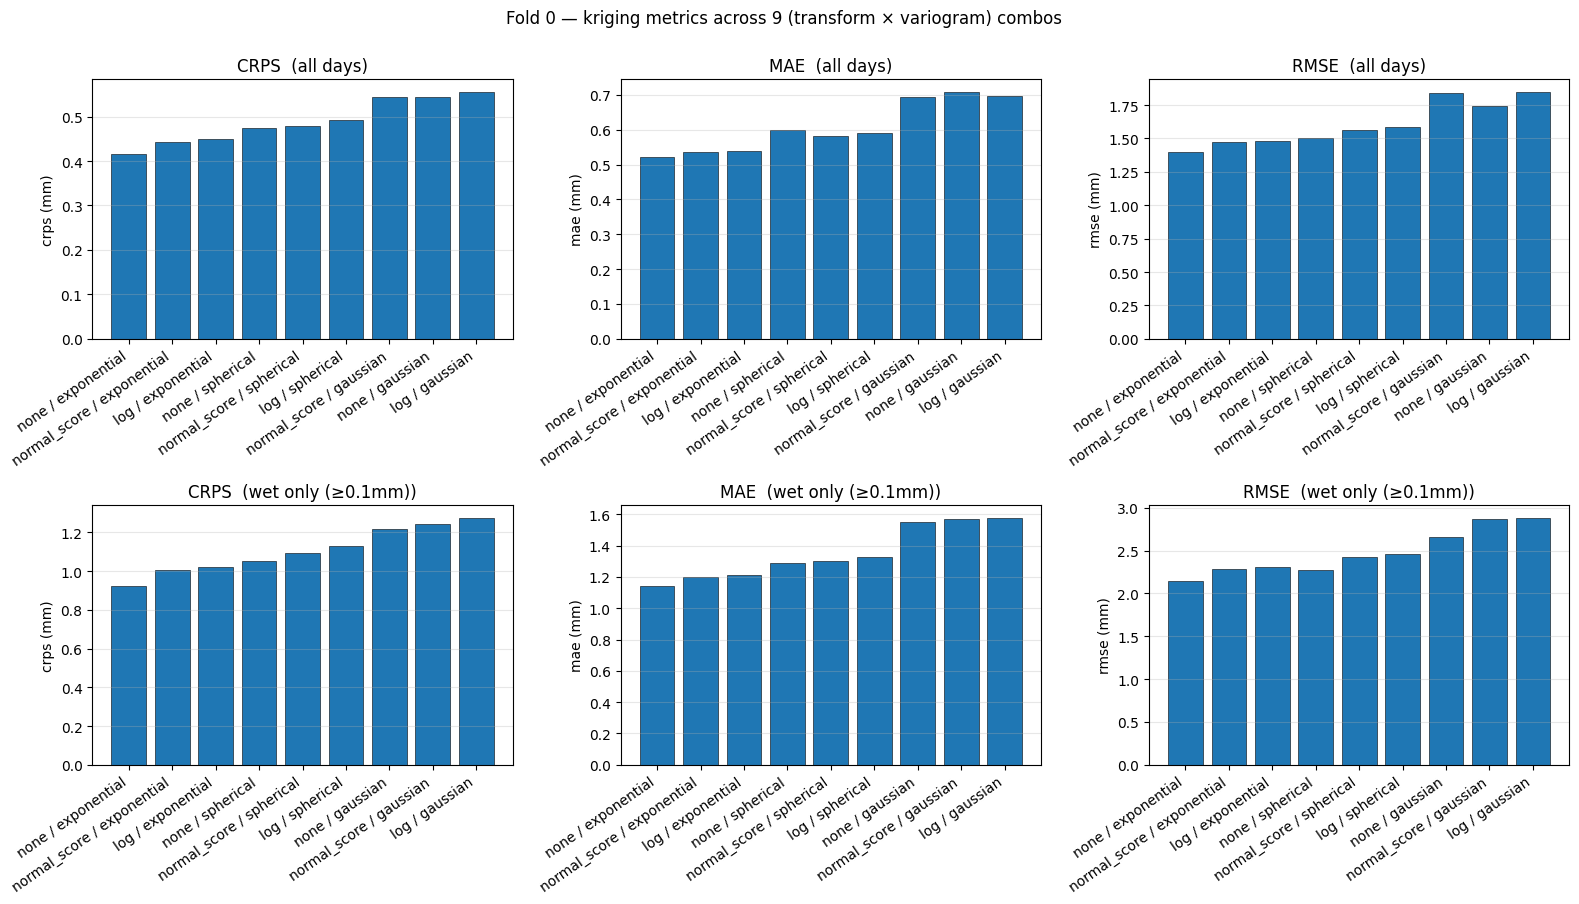

saved → outputs/kriging/eval/fold0/metrics_bar.png


In [4]:
def _plot_bars(df_m, title_suffix, ax_set):
    df_m = df_m.copy()
    df_m['combo'] = df_m['transform'] + ' / ' + df_m['variogram_model']
    df_m = df_m.sort_values('crps')
    for ax, metric in zip(ax_set, ['crps', 'mae', 'rmse']):
        ax.bar(df_m['combo'], df_m[metric], color='C0', edgecolor='k', linewidth=0.4)
        ax.set_title(f'{metric.upper()}  ({title_suffix})')
        ax.set_ylabel(f'{metric} (mm)')
        plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
        ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
_plot_bars(metrics_all, 'all days',          axes[0])
_plot_bars(metrics_wet, 'wet only (≥0.1mm)', axes[1])
plt.suptitle(f'Fold {FOLD} — kriging metrics across 9 (transform × variogram) combos', y=1.00)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved → {EVAL_DIR}/metrics_bar.png')

## 4. Coverage diagnostic

Target levels: 0.80 for 80% PI, 0.90 for 90% PI. Under/over-coverage is visible at a glance.

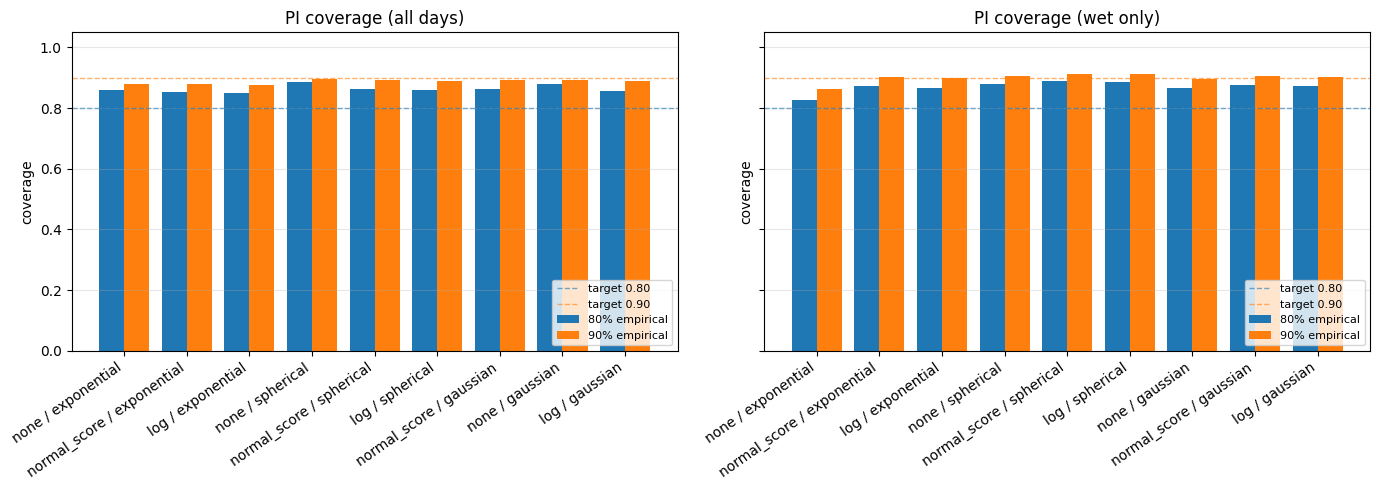

saved → outputs/kriging/eval/fold0/coverage.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, df_m, label in zip(axes, [metrics_all, metrics_wet], ['all days', 'wet only']):
    df_m = df_m.copy()
    df_m['combo'] = df_m['transform'] + ' / ' + df_m['variogram_model']
    df_m = df_m.sort_values('crps')
    x = np.arange(len(df_m))
    ax.bar(x - 0.2, df_m['cov80'], width=0.4, color='C0', label='80% empirical')
    ax.bar(x + 0.2, df_m['cov90'], width=0.4, color='C1', label='90% empirical')
    ax.axhline(0.80, color='C0', ls='--', lw=1, alpha=0.6, label='target 0.80')
    ax.axhline(0.90, color='C1', ls='--', lw=1, alpha=0.6, label='target 0.90')
    ax.set_xticks(x)
    ax.set_xticklabels(df_m['combo'], rotation=35, ha='right')
    ax.set_ylabel('coverage')
    ax.set_title(f'PI coverage ({label})')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(EVAL_DIR / 'coverage.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved → {EVAL_DIR}/coverage.png')

## 5. Winner: scatter, map, time series

All three plots use the combo with the lowest all-days CRPS.

In [6]:
WIN_T  = winner.loc['transform']
WIN_VM = winner.loc['variogram_model']
win_df = df[(df['transform'] == WIN_T) & (df['variogram_model'] == WIN_VM)].dropna(
    subset=['predicted_mm', 'predicted_var_mm2']).copy()
win_df['sd']    = np.sqrt(np.clip(win_df['predicted_var_mm2'], 1e-8, None))
win_df['q05']   = np.clip(win_df['predicted_mm'] - Z90 * win_df['sd'], 0, None)
win_df['q10']   = np.clip(win_df['predicted_mm'] - Z80 * win_df['sd'], 0, None)
win_df['q90']   = win_df['predicted_mm'] + Z80 * win_df['sd']
win_df['q95']   = win_df['predicted_mm'] + Z90 * win_df['sd']
win_df['err']   = win_df['predicted_mm'] - win_df['observed_mm']

# Station coordinates: ReKISSource.load_stations() returns the long-form table
# (station_id, date, lon, lat, elevation_m, precip_mm). Keep one row per station.
from thesis.data.registry import DataRegistry
registry = DataRegistry.from_config(cfg)
stations_long = registry.stations.load_stations()
stations = (stations_long[['station_id', 'lon', 'lat']]
            .drop_duplicates('station_id')
            .rename(columns={'lon': 'longitude', 'lat': 'latitude'}))
win_df = win_df.merge(stations, on='station_id', how='left')
n_missing_coords = win_df['longitude'].isna().sum()
if n_missing_coords:
    print(f'  WARN: {n_missing_coords} records have no coordinates and will be dropped from the map')
    win_df = win_df.dropna(subset=['longitude', 'latitude'])

per_station = (
    win_df.groupby(['station_id', 'longitude', 'latitude'])
          .agg(rmse=('err', lambda e: float(np.sqrt(np.mean(e**2)))),
               mae =('err', lambda e: float(np.mean(np.abs(e)))),
               n   =('err', 'size'))
          .reset_index()
)
print(f'winner: {WIN_T}/{WIN_VM}   stations: {len(per_station)}   records: {len(win_df):,}')
per_station.describe()[['rmse', 'mae', 'n']]

winner: <bound method Series.transform of transform                 none
variogram_model    exponential
n                      9065940
pct                      100.0
rmse                  1.401063
mae                   0.523323
bias                  0.052459
crps                  0.416698
cov80                  0.86146
cov90                 0.879491
Name: 0, dtype: object>/exponential   stations: 0   records: 0


,rmse,mae,n
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


ValueError: Axis limits cannot be NaN or Inf

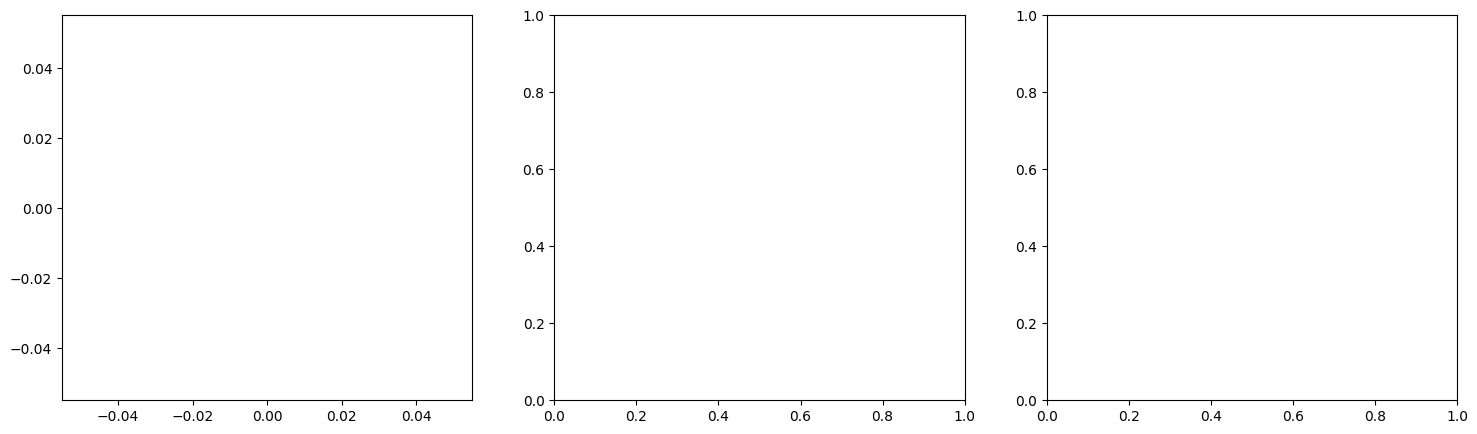

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Pred vs Obs scatter with 80%/90% PI (yerr clipped at 0)
ax = axes[0]
yerr_lo_90 = np.clip(win_df['predicted_mm'] - win_df['q05'], 0, None)
yerr_hi_90 = np.clip(win_df['q95'] - win_df['predicted_mm'], 0, None)
yerr_lo_80 = np.clip(win_df['predicted_mm'] - win_df['q10'], 0, None)
yerr_hi_80 = np.clip(win_df['q90'] - win_df['predicted_mm'], 0, None)
ax.errorbar(win_df['observed_mm'], win_df['predicted_mm'],
            yerr=[yerr_lo_90, yerr_hi_90], fmt='none',
            alpha=0.10, ecolor='lightgray', elinewidth=0.5,
            label='90% PI')
ax.errorbar(win_df['observed_mm'], win_df['predicted_mm'],
            yerr=[yerr_lo_80, yerr_hi_80], fmt='.', ms=2,
            alpha=0.30, ecolor='gray', elinewidth=0.7,
            label='80% PI')
hi = float(max(win_df['observed_mm'].quantile(0.999),
               win_df['predicted_mm'].quantile(0.999))) * 1.05
ax.plot([0, hi], [0, hi], 'r--', lw=1, label='1:1')
ax.set(xlim=(0, hi), ylim=(0, hi),
       xlabel='Observed (mm)', ylabel='Predicted (mm)',
       title=f'Pred vs Obs  ({WIN_T}/{WIN_VM}, N={len(win_df):,})')
ax.legend(); ax.grid(alpha=0.3)

# (2) Station map coloured by per-station RMSE
ax = axes[1]
sc = ax.scatter(per_station['longitude'], per_station['latitude'],
                c=per_station['rmse'], s=70, cmap='viridis',
                edgecolor='k', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='Per-station RMSE (mm)')
ax.set(xlabel='Longitude', ylabel='Latitude',
       title=f'Test stations (n={len(per_station)})')
ax.grid(alpha=0.3); ax.set_aspect('equal', adjustable='datalim')

# (3) Time series for the station closest to the median RMSE (first year for readability)
median_rmse = per_station['rmse'].median()
ex = per_station.iloc[(per_station['rmse'] - median_rmse).abs().argmin()]
ts = win_df[win_df['station_id'] == ex.station_id].sort_values('date').iloc[:365]
ax = axes[2]
ax.fill_between(ts['date'], ts['q05'], ts['q95'],
                alpha=0.18, color='C0', label='90% PI')
ax.fill_between(ts['date'], ts['q10'], ts['q90'],
                alpha=0.30, color='C0', label='80% PI')
ax.plot(ts['date'], ts['predicted_mm'], 'C0-',  lw=1.2, label='predicted')
ax.plot(ts['date'], ts['observed_mm'],  'k.-',  ms=4,  label='observed')
ax.set(xlabel='Date', ylabel='Rainfall (mm)',
       title=f'Station {ex.station_id} (RMSE={ex.rmse:.2f} mm, first year)')
ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.savefig(EVAL_DIR / 'winner_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved → {EVAL_DIR}/winner_diagnostics.png')

## 6. Error breakdown by rainfall bucket

Where does the model lose: on dry days, light rain or extremes? Group by observed-rainfall buckets and look at RMSE/bias inside each.

In [ ]:
BUCKETS = [(0, 0.1, 'dry'),
           (0.1, 1, '0.1–1 mm'),
           (1, 5, '1–5 mm'),
           (5, 10, '5–10 mm'),
           (10, 25, '10–25 mm'),
           (25, np.inf, '>25 mm')]

rows = []
for lo, hi, name in BUCKETS:
    sub = win_df[(win_df['observed_mm'] >= lo) & (win_df['observed_mm'] < hi)]
    if len(sub) == 0:
        continue
    err = sub['predicted_mm'] - sub['observed_mm']
    rows.append({
        'bucket'  : name,
        'n'       : len(sub),
        'pct'     : 100 * len(sub) / len(win_df),
        'rmse'    : float(np.sqrt(np.mean(err**2))),
        'mae'     : float(np.mean(np.abs(err))),
        'bias'    : float(np.mean(err)),
        'mean_pred': float(sub['predicted_mm'].mean()),
        'mean_obs' : float(sub['observed_mm'].mean()),
    })
buckets_df = pd.DataFrame(rows)
print(f'Error breakdown by observed rainfall bucket  ({WIN_T}/{WIN_VM})')
print(buckets_df.to_string(index=False, float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else str(x)))
buckets_df.to_csv(EVAL_DIR / 'error_by_bucket.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(buckets_df))
axes[0].bar(x - 0.2, buckets_df['rmse'], width=0.4, color='C0', label='RMSE')
axes[0].bar(x + 0.2, buckets_df['mae'],  width=0.4, color='C1', label='MAE')
axes[0].set_xticks(x); axes[0].set_xticklabels(buckets_df['bucket'], rotation=20, ha='right')
axes[0].set_ylabel('mm'); axes[0].set_title('Error magnitude by bucket')
axes[0].grid(axis='y', alpha=0.3); axes[0].legend()

axes[1].bar(x, buckets_df['bias'], color=['C2' if b > 0 else 'C3' for b in buckets_df['bias']])
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels(buckets_df['bucket'], rotation=20, ha='right')
axes[1].set_ylabel('bias (pred - obs, mm)')
axes[1].set_title('Bias by bucket  (green = over-prediction, red = under-prediction)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'error_by_bucket.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved → {EVAL_DIR}/error_by_bucket.{{csv,png}}')

## 7. Summary

If kriging gives CRPS_wet ≈ 0.7–1.0 mm and BayesNF on the same fold0/2020 scored 1.07, that is a close match. The table below collects the final numbers for comparison.

In [ ]:
print('=== FOLD 0 SUMMARY (kriging) ===\n')
print(f'Winner (all days, lowest CRPS):  {WIN_T} / {WIN_VM}')
for col in ['rmse', 'mae', 'bias', 'crps', 'cov80', 'cov90']:
    print(f'  {col:8s}: {winner[col]:.4f}')

win_t_wet  = winner_wet.loc['transform']
win_vm_wet = winner_wet.loc['variogram_model']
print(f'\nWinner (wet only):  {win_t_wet} / {win_vm_wet}')
for col in ['rmse', 'mae', 'bias', 'crps', 'cov80', 'cov90']:
    print(f'  {col:8s}: {winner_wet[col]:.4f}')

print(f'\nartifacts → {EVAL_DIR}')
for p in sorted(EVAL_DIR.glob('*')):
    print(f'  {p.name}  ({p.stat().st_size/1e3:.1f} KB)')